Name: Jaxon Schroeder
Date: 9/13/2026
Machine Learning


['selling_price', 'km_driven', 'mileage', 'torque', 'seats', 'Diesel', 'LPG', 'Petrol']
KNN RMSE: 477693.6209409745
KNN R²: 0.6601880801030126
Elastic Net RMSE: 736184.6471041589
Elastic Net R²: 0.19292622129849912


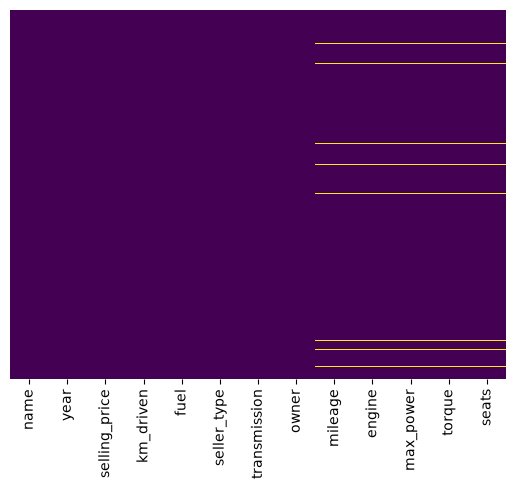

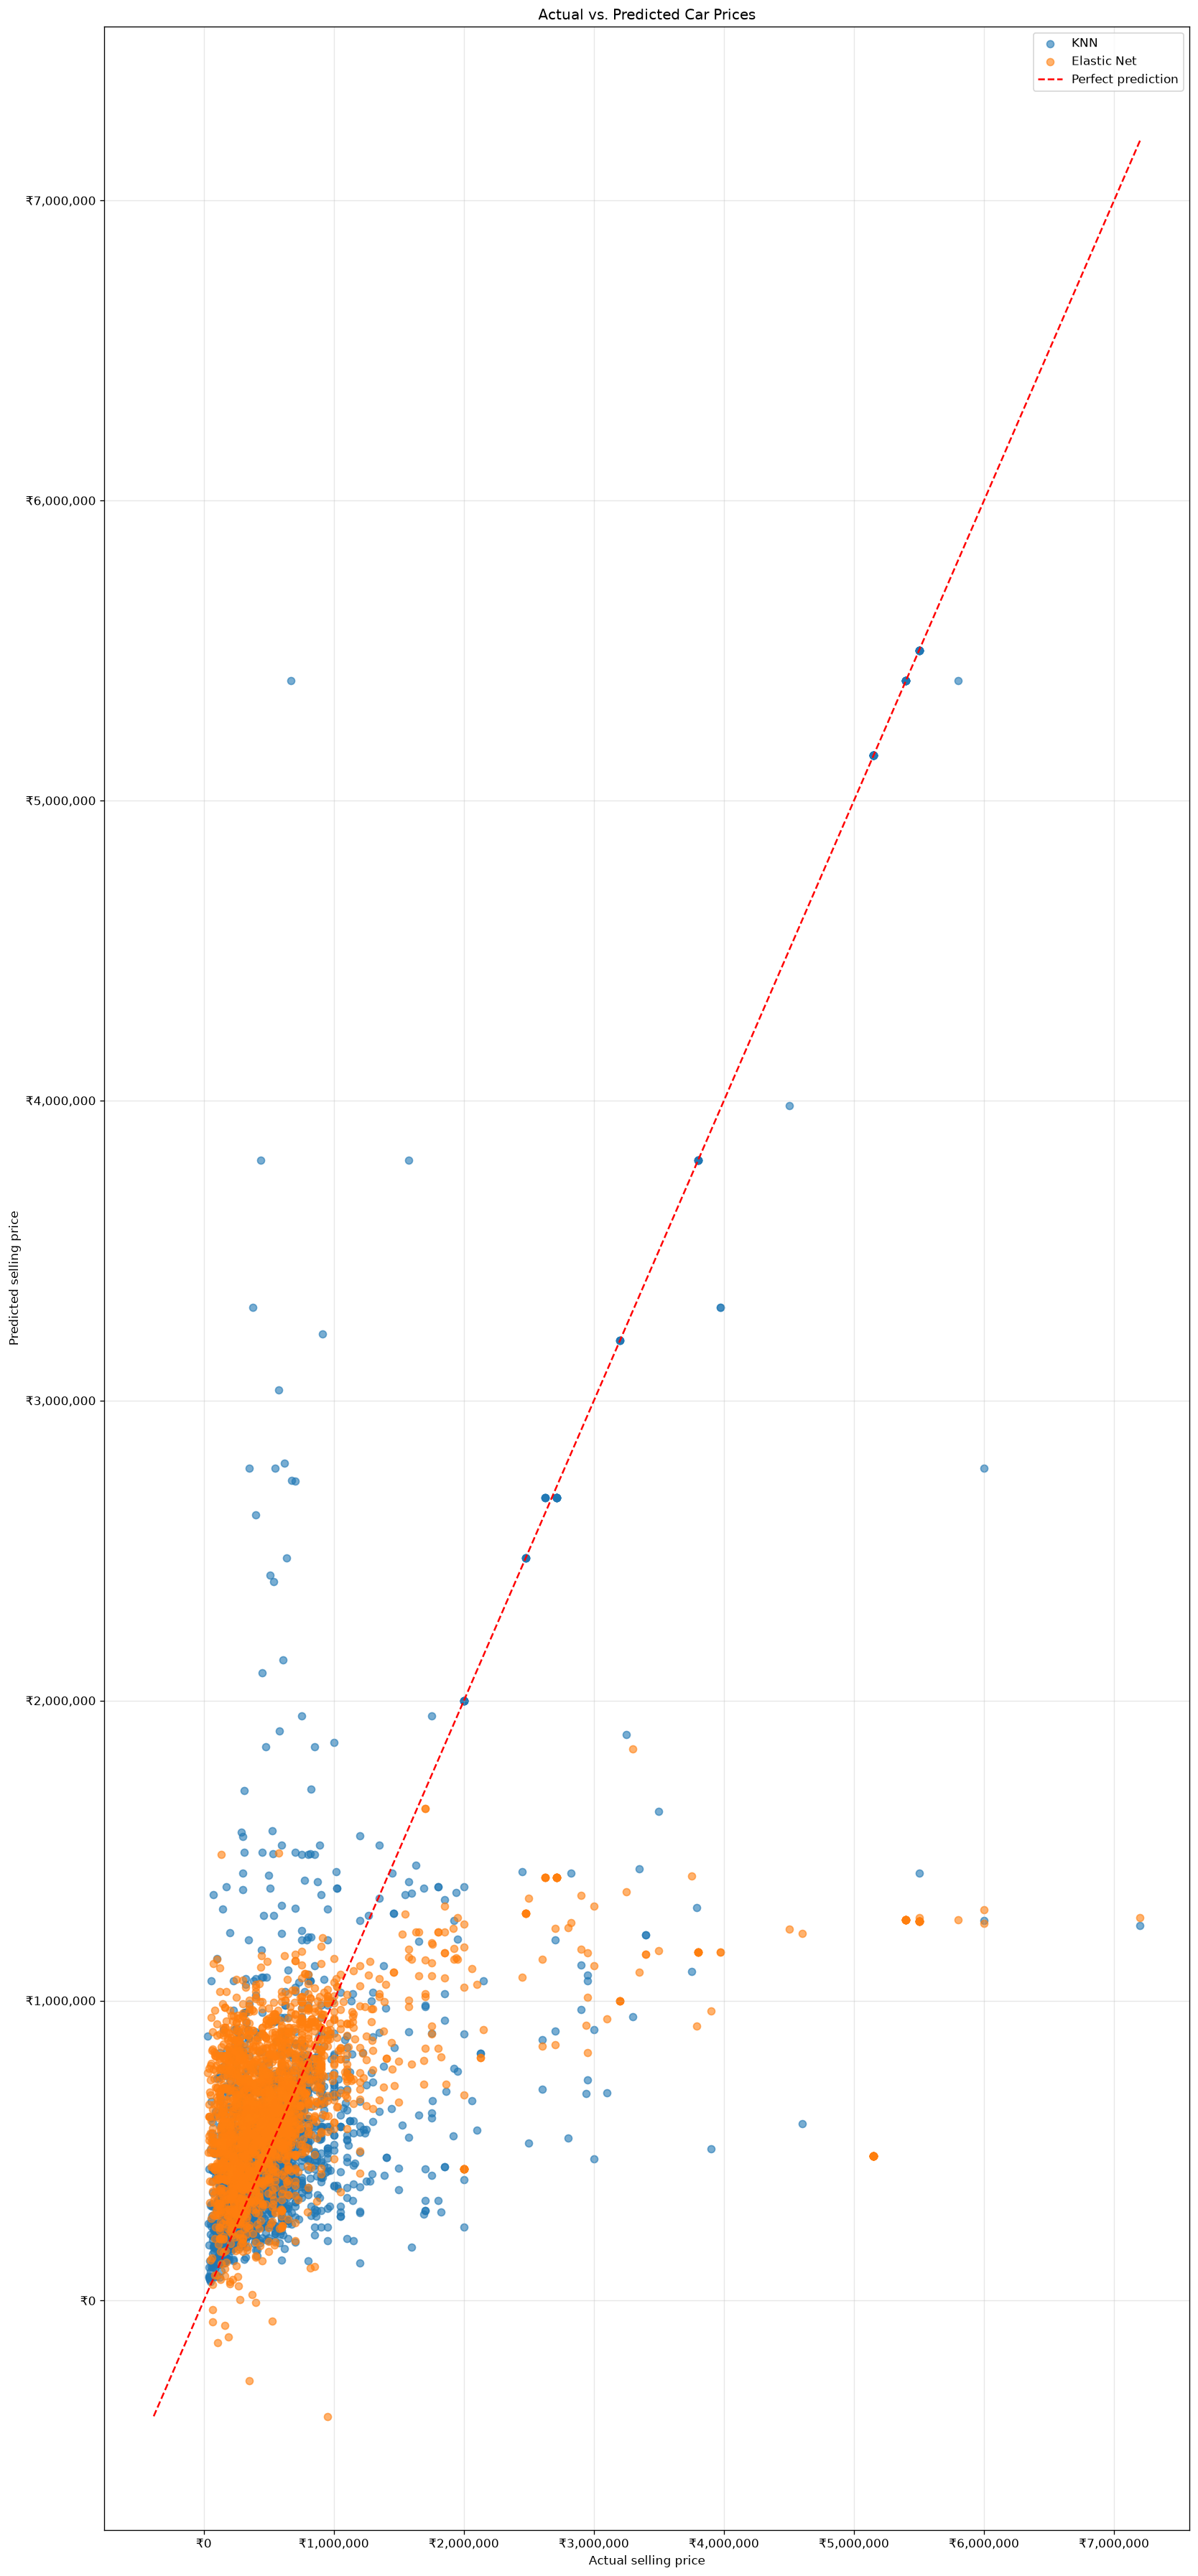

In [36]:
#Import everything that is needed
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import ElasticNet

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from matplotlib.ticker import FuncFormatter

from sklearn.metrics import mean_squared_error, r2_score
def price_formatter(value, position):
    return f"₹{value:,.0f}"

#Load the dataset
data = pd.read_csv('car_dataset.csv')

knnModel = KNeighborsRegressor(n_neighbors=5)
enModel = ElasticNet(alpha=0.1, l1_ratio=0.3)

missing_values = data.isnull()
sns.heatmap(data = missing_values, yticklabels=False, cbar=False, cmap='viridis')
data.drop(columns=['name', 'year', 'seller_type', 'engine', 'transmission', 'owner', 'max_power'], inplace=True)

fuel_type = pd.get_dummies(data['fuel'], drop_first=True) # drop first means k-1 values
data.drop(columns=['fuel'], inplace=True)
data = pd.concat([data, fuel_type], axis=1)
print(data.columns.tolist())
data.dropna(inplace=True)
data['mileage'] = pd.to_numeric(
    data['mileage'].astype(str).str.extract(r'([\d.]+)')[0],
    errors='coerce'
)
data['seats'] = pd.to_numeric(data['seats'], errors='coerce')
data['km_driven'] = pd.to_numeric(data['km_driven'], errors='coerce')
data['selling_price'] = pd.to_numeric(data['selling_price'], errors='coerce')
X = data[['km_driven', 'mileage', 'seats', 'Diesel', 'Petrol', 'LPG']]
y = data[['selling_price']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)

enModel.fit(X_train, y_train)
knnModel.fit(X_train, y_train)

knn_predictions = knnModel.predict(X_test)
knn_rmse = np.sqrt(mean_squared_error(y_test, knn_predictions))
knn_r2 = r2_score(y_test, knn_predictions)

print("KNN RMSE:", knn_rmse)
print("KNN R²:", knn_r2)

en_predictions = enModel.predict(X_test)
en_rmse = np.sqrt(mean_squared_error(y_test, en_predictions))
en_r2 = r2_score(y_test, en_predictions)

print("Elastic Net RMSE:", en_rmse)
print("Elastic Net R²:", en_r2)

plt.figure(figsize=(14, 30), dpi=120)
plt.scatter(y_test, knn_predictions, alpha=0.6, label="KNN")
plt.scatter(y_test, en_predictions, alpha=0.6, label="Elastic Net")

plt.gca().xaxis.set_major_formatter(FuncFormatter(price_formatter))
plt.gca().yaxis.set_major_formatter(FuncFormatter(price_formatter))

minimum = min(y_test['selling_price'].min(), knn_predictions.min(), en_predictions.min())
maximum = max(y_test['selling_price'].max(), knn_predictions.max(), en_predictions.max())

plt.plot([minimum, maximum], [minimum, maximum], 'r--', label="Perfect prediction")
plt.xlabel("Actual selling price")
plt.ylabel("Predicted selling price")
plt.title("Actual vs. Predicted Car Prices")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The Elastic Net model is useful for finding a more regularized section of the data set. The Knn regression model works well at finding accurate prices based on proximity of other values.

The elastic model is somewhat accurate at lower price ranges, while the Knn model becomes more accurate as the price rises.  While I focused on factors that would be relevant to a cars price, such as number of seats, mileage, and fuel type to train for selling price, I notice that there are some major outliars, so tuning the knn_regression model to be closer to an overfitted model, while the weighting for the Elastic net model may need to be increased as the perdctions are close, but off kilter from the correct perdiction.